# Project 2: Prediction of Molecule Properties with Machine Learning
#### Authors: Aleksandra Dmitruk & Julia Michalska

##### Chosen dataset
We chose the dataset *Acute Toxicity LD50*. Acute toxicity LD50 measures the most conservative dose that can lead to lethal adverse effects. The higher the dose, the more lethal of a drug [1]. To predict the drugs toxicity regression will be used. The dataset contains 7,385 drugs.


[1]: [Toxicity - TDC](https://tdcommons.ai/single_pred_tasks/tox/)


In [18]:
# All required libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from rdkit import Chem
from rdkit.Chem import MolToInchi, MolToInchiKey, Draw, rdFingerprintGenerator, Descriptors, AllChem
from rdkit import DataStructs
from rdkit.ML.Cluster import Butina
import xgboost as xgb
from sklearn.metrics import accuracy_score
from IPython.display import display, Image
from sklearn.model_selection import train_test_split
import umap
import seaborn as sns
from tdc.single_pred import Tox


ModuleNotFoundError: No module named 'tdc'

### TASK 1: Load and Inspect Chosen Dataset

In [ ]:
data = Tox(name = 'LD50_Zhu')

Found local copy...
Loading...
Done!


In [ ]:
tox_df = data.get_data()
tox_df


,Drug_ID,Drug,Y
0,"Diazene, diphenyl-, 1-oxide",[O-][N+](=Nc1ccccc1)c1ccccc1,2.505
1,"Methane, tribromo-",BrC(Br)Br,2.343
2,Bromoethene (9CI),C=CBr,2.330
3,"1,1'-Biphenyl, hexabromo-",Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465
4,"Isothiocyanic acid, p-bromophenyl ester",S=C=Nc1ccc(Br)cc1,2.729
...,...,...,...
7380,"Isocyanic acid, (alpha,alpha,alpha-trifluoro-o...",O=C=Nc1ccccc1C(F)(F)F,1.427
7381,"1,3-Benzenediamine, 4-(1,1,2,2-tetrafluoroetho...",Nc1ccc(OC(F)(F)C(F)F)c(N)c1,2.321
7382,"Propanenitrile, 3-((2-(acetyloxy)ethyl)phenyla...",CC(=O)OCCN(CCC#N)c1ccccc1,2.050
7383,"IH-Indene-1,3(2H)-dione, 2-(2-methyl-1-(2-(1-p...",CC1=CC(=C2C(=O)c3ccccc3C2=O)C=CN1CCN1CCCCC1,2.951


**Dataset columns:**
- `Drug_ID`: Molecule name
- `Y`: Target label. LD50 (Lethal Dose, 50%). The value of LD50 for a substance is the dose required to kill half the members of a tested population after a specified test duration. Unit: −log10​(mol/kg), 5.0 - 7.0 means very toxic, 0.1 - 2.0 means relatively non-toxic.
- `Drug`: SMILES string representation of the molecule

In [ ]:
split = data.get_split()
split

{'train':                                                 Drug_ID  \
 0                                    Methane, tribromo-   
 1                                     Bromoethene (9CI)   
 2                             1,1'-Biphenyl, hexabromo-   
 3               Isothiocyanic acid, p-bromophenyl ester   
 4                                       Benzene, bromo-   
 ...                                                 ...   
 5165      Benzenesulfonic acid, 3,5-dimethyl-4-hydroxy-   
 5166  Isocyanic acid, (alpha,alpha,alpha-trifluoro-o...   
 5167  Propanenitrile, 3-((2-(acetyloxy)ethyl)phenyla...   
 5168  IH-Indene-1,3(2H)-dione, 2-(2-methyl-1-(2-(1-p...   
 5169           1-Propanone, 1-(2,4,6-trihydroxyphenyl)-   
 
                                              Drug      Y  
 0                                       BrC(Br)Br  2.343  
 1                                           C=CBr  2.330  
 2           Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br  1.465  
 3                           

We create a new column with the converted molecule objects using RDKit. We drop any columns that may have not be parsed.

In [ ]:
tox_df["Molecule"] = tox_df["Drug"].apply(lambda x: Chem.MolFromSmiles(x))
tox_df = tox_df.dropna(subset=['Molecule'])

Now we compute basic descriptors using Descriptors module from RDKit.

In [ ]:
tox_df['MW'] = tox_df['Molecule'].apply(lambda x: Descriptors.MolWt(x) if x else None) # size proxy - affects absorption and  distribution
tox_df['LogP'] = tox_df['Molecule'].apply(lambda x: Descriptors.MolLogP(x) if x else None) # membrane permeability
tox_df['H_Donors'] = tox_df['Molecule'].apply(lambda x: Descriptors.NumHDonors(x) if x else None) # pharmacokinetic profile
tox_df['H_acceptors'] = tox_df['Molecule'].apply(lambda x: Descriptors.NumHAcceptors(x) if x else None) # solubility, transport
tox_df['RotBonds'] = tox_df['Molecule'].apply(lambda x: Descriptors.NumRotatableBonds(x) if x else None) # molecular flexibility
tox_df['MaxPartCharge'] = tox_df['Molecule'].apply(lambda x: Descriptors.MaxPartialCharge(x) if x else None) # electrostatic interactions strongly impact a drug's toxicity profile
tox_df['MinPartCharge'] = tox_df['Molecule'].apply(lambda x: Descriptors.MinPartialCharge(x) if x else None) 

In [ ]:
tox_df.head(5)

,Drug_ID,Drug,Y,Molecule,MW,LogP,H_Donors,H_acceptors,RotBonds,MaxPartCharge,MinPartCharge
0,"Diazene, diphenyl-, 1-oxide",[O-][N+](=Nc1ccccc1)c1ccccc1,2.505,<rdkit.Chem.rdchem.Mol object at 0x000001951EE...,198.225,3.6123,0,2,2,0.244409,-0.593884
1,"Methane, tribromo-",BrC(Br)Br,2.343,<rdkit.Chem.rdchem.Mol object at 0x000001951F5...,252.731,2.4547,0,0,0,0.124221,-0.063717
2,Bromoethene (9CI),C=CBr,2.330,<rdkit.Chem.rdchem.Mol object at 0x000001951F5...,106.950,1.5248,0,0,0,-0.026096,-0.092103
3,"1,1'-Biphenyl, hexabromo-",Brc1ccc(-c2ccc(Br)c(Br)c2Br)c(Br)c1Br,1.465,<rdkit.Chem.rdchem.Mol object at 0x000001951F5...,627.588,7.9286,0,0,1,0.046537,-0.052002
4,"Isothiocyanic acid, p-bromophenyl ester",S=C=Nc1ccc(Br)cc1,2.729,<rdkit.Chem.rdchem.Mol object at 0x000001951F5...,214.087,3.1834,0,2,1,0.073984,-0.194738


In [ ]:
tox_df.describe()

,Y,MW,LogP,H_Donors,H_acceptors,RotBonds,MaxPartCharge,MinPartCharge
count,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000,7385.000000
mean,2.544400,247.546950,2.473243,0.788219,3.223968,3.968450,0.246540,-0.382737
std,0.958667,115.414984,1.821588,1.164827,2.239202,3.520518,0.132285,0.100198
min,-0.343000,30.026000,-15.230600,0.000000,0.000000,0.000000,-0.070082,-0.869925
25%,1.856000,164.204000,1.316100,0.000000,2.000000,1.000000,0.137261,-0.465321
50%,2.368000,233.227000,2.370500,0.000000,3.000000,3.000000,0.262078,-0.393124
75%,3.035000,309.837000,3.571000,1.000000,4.000000,6.000000,0.335391,-0.324383
max,10.207000,1268.883000,14.286060,21.000000,35.000000,33.000000,0.954944,-0.014827


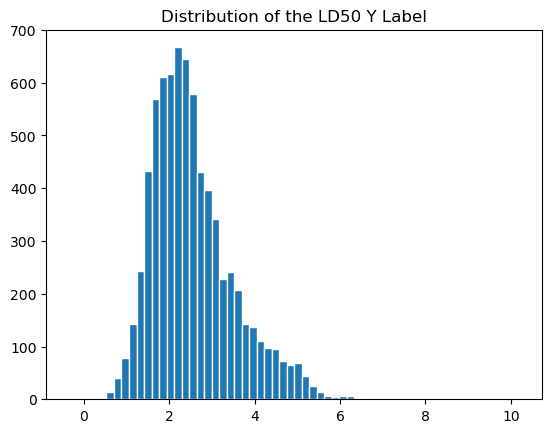

In [ ]:
plt.hist(tox_df["Y"], bins = 60, edgecolor = "white")
plt.title("Distribution of the LD50 Y Label")
plt.show()

As we can see, most of the drugs in our dataset have lower toxicity.

### TASK 2: Duplicate Molecules and Label Consistency

We will add a column that will contain the InChIKeys for the drugs in our dataset.

In [ ]:
tox_df['InChIKey'] = tox_df['Molecule'].apply(lambda x: Chem.MolToInchiKey(x) if x else None)

In [ ]:
len(tox_df["InChIKey"]) - len(tox_df["InChIKey"].unique())

43

We have 43 rows with duplicated drugs (drugs that repeat an InChIKey). Let's see what all the duplicates are.

In [ ]:
duplicates = tox_df[tox_df.duplicated(subset='InChIKey', keep=False)].sort_values('InChIKey')
duplicates.head(5)

,Drug_ID,Drug,Y,Molecule,MW,LogP,H_Donors,H_acceptors,RotBonds,MaxPartCharge,MinPartCharge,InChIKey
5435,Escin,CC=C(C)C(=O)OC1C(OC(C)=O)C2(CO)C(O)CC3(C)C(=CC...,3.133,<rdkit.Chem.rdchem.Mol object at 0x000001951F6...,1131.269,-1.3211,13,23,14,0.335304,-0.479243,AXNVHPCVMSNXNP-UHFFFAOYSA-N
4066,alpha-Aescin,CC=C(C)C(=O)OC1C(OC(C)=O)C2(CO)C(O)CC3(C)C(=CC...,3.196,<rdkit.Chem.rdchem.Mol object at 0x000001951F5...,1131.269,-1.3211,13,23,14,0.335304,-0.479243,AXNVHPCVMSNXNP-UHFFFAOYSA-N
6411,"1,3-Oxathiolan-4-one, 2-methyl-, O-((methylami...",CNC(=O)ON=C1COC(C)S1,4.200,<rdkit.Chem.rdchem.Mol object at 0x000001951F6...,190.224,0.7653,1,5,1,0.432615,-0.360489,BHQUYFUCFMPJTA-UHFFFAOYSA-N
6425,"1,3-Oxathiolan-4-one, 2-methyl-, O-((methylami...",CNC(=O)ON=C1COC(C)S1,3.589,<rdkit.Chem.rdchem.Mol object at 0x000001951F6...,190.224,0.7653,1,5,1,0.432615,-0.360489,BHQUYFUCFMPJTA-UHFFFAOYSA-N
4437,"1-Indancarboxylic acid, 5-cyclohexyl-, methyl ...",COC(=O)C1CCc2cc(C3CCCCC3)ccc21,3.007,<rdkit.Chem.rdchem.Mol object at 0x000001951F5...,258.361,3.9371,0,2,2,0.312654,-0.468546,CPBGSLIVFJMDAK-UHFFFAOYSA-N


In [ ]:
table_std = duplicates.groupby("InChIKey")["Y"].std().reset_index(name="Std of Y")
table_std.head(10)

,InChIKey,Std of Y
0,AXNVHPCVMSNXNP-UHFFFAOYSA-N,0.044548
1,BHQUYFUCFMPJTA-UHFFFAOYSA-N,0.432042
2,CPBGSLIVFJMDAK-UHFFFAOYSA-N,0.147078
3,CXBMCYHAMVGWJQ-UHFFFAOYSA-N,0.016971
4,DFBKLUNHFCTMDC-UHFFFAOYSA-N,0.782060
5,FBOUIAKEJMZPQG-UHFFFAOYSA-N,0.000000
6,GQNBIMLHUAWKHJ-UHFFFAOYSA-N,0.461034
7,HZAWPPRBCALFRN-UHFFFAOYSA-N,0.246780
8,IISXXZMZLSKUTJ-UHFFFAOYSA-N,0.000000
9,KFUSEUYYWQURPO-UHFFFAOYSA-N,0.144957


Only some duplicates have the same Y label. Others have some variance to them. This may be due to some experimental noise or different conditions during testing. Multiple LD50 labels for the same drug are going to make our predictions later weaker. We would also like to avoid a situation in which the duplicates with matching Y labels are in both training and testing set (we want to avoid data leakage). We will drop all duplicates with the same Y label. For those that don't match, we will leave only the highest value as a precaution.

In [ ]:
tox_df = tox_df.sort_values("Y", ascending= False).drop_duplicates(subset="InChIKey", keep = "first")
tox_df.head(5)

,Drug_ID,Drug,Y,Molecule,MW,LogP,H_Donors,H_acceptors,RotBonds,MaxPartCharge,MinPartCharge,InChIKey
1987,"Dibenzo(b,e)(1,4)dioxin, 2,3,7,8-tetrachloro-",Clc1cc2c(cc1Cl)Oc1cc(Cl)c(Cl)cc1O2,10.207,<rdkit.Chem.rdchem.Mol object at 0x000001951F5...,321.974,6.1982,0,2,0,0.171248,-0.449397,HGUFODBRKLSHSI-UHFFFAOYSA-N
1933,"Dibenzo-p-dioxin, 1,2,3,4-tetrachloro-",Clc1c(Cl)c(Cl)c2c(c1Cl)Oc1ccccc1O2,8.605,<rdkit.Chem.rdchem.Mol object at 0x000001951F5...,321.974,6.1982,0,2,0,0.191407,-0.447804,DJHHDLMTUOLVHY-UHFFFAOYSA-N
5434,"9,10-Secocholesta-5,7,10(19)-triene-1,3,25-tri...",C=C1C(=CC=C2CCCC3(C)C2CCC3C(C)CCCC(O)(C(F)(F)F...,7.100,<rdkit.Chem.rdchem.Mol object at 0x000001951F6...,524.586,6.7895,3,3,6,0.425758,-0.392670,XPYGGHVSFMUHLH-UHFFFAOYSA-N
5936,"Dibenzo(b,e)(1,4)dioxin, 2,3,7,8-tetrabromo-",Brc1cc2c(cc1Br)Oc1cc(Br)c(Br)cc1O2,6.699,<rdkit.Chem.rdchem.Mol object at 0x000001951F6...,499.778,6.6346,0,2,0,0.170861,-0.449426,JZLQUWSWOJPCAK-UHFFFAOYSA-N
6681,"2H-1-Benzopyran-2-one, 3-(3-(4'-bromo(1,1'-bip...",O=c1oc2ccccc2c(O)c1C1CC(c2ccc(-c3ccc(Br)cc3)cc...,6.515,<rdkit.Chem.rdchem.Mol object at 0x000001951F6...,523.426,7.7900,1,3,3,0.343352,-0.506592,VEUZZDOCACZPRY-UHFFFAOYSA-N


### TASK 3: Missing or Undefined Stereochemistry

In [ ]:
unassigned_counts = []
molecules_with_unassigned = []

for i, row in tox_df.iterrows():
    mol = row["Molecule"]
    chiral_centers = Chem.FindMolChiralCenters(mol, includeUnassigned=True)
    counts = sum(1 for _, chirality in chiral_centers if chirality == '?')
    
    unassigned_counts.append(counts)
    if counts > 0:
        molecules_with_unassigned.append(row)

tox_df["unassigned_counts"] = unassigned_counts

In [ ]:
unassigned = pd.DataFrame(molecules_with_unassigned)

In [ ]:
print(f"\nStereocenter analysis:")
print(f"  Total molecules analyzed: {len(tox_df)}")
print(f"  Molecules with unassigned stereocenters: {len(unassigned)}")
print(f"  Molecules with unassigned stereocenters [%]: {round(len(unassigned)/len(tox_df)*100, 2)}")
print(f"  Total unassigned stereocenters: {sum(unassigned_counts)}")


Stereocenter analysis:
  Total molecules analyzed: 7342
  Molecules with unassigned stereocenters: 2164
  Molecules with unassigned stereocenters [%]: 29.47
  Total unassigned stereocenters: 4744


We identified how many molecules have missing stereochemistry and how many missing chiral centers each molecule has. Below we will show the distribution of the number of missing chiral centers.

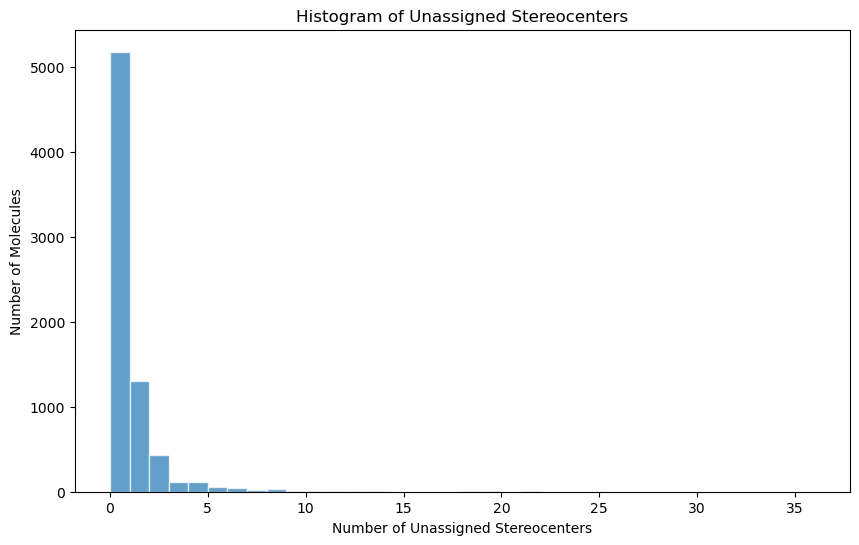

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(unassigned_counts, bins=range(max(unassigned_counts) + 2), edgecolor='white', alpha=0.7)
plt.xlabel('Number of Unassigned Stereocenters')
plt.ylabel('Number of Molecules')
plt.title('Histogram of Unassigned Stereocenters')
plt.show()

Could stereochemistry affect the label? In case of our dataset, it cretainly can. Because our Y label measures toxicity and biological systems are highly stereospecific, so one enantiomer of a drug might be a medicine, while its mirror image could be highly toxic to the human body. Undefined stereochemistry could potentially lead to the model confusion about the lethality of the drug. 

Should such molecules be removed or standardized? Molecules with missing or undefined stereochemistry make up almost 30% of our dataset. Removing them would thin out the dataset significantly. In such a case, we resort to standarization to 2D of the affected molecules. It will introduce some noise to the dataset, but 30% of data would be a significant loss.

In [ ]:
def standardize(mol):
    if mol is None:
        return None
    
    mol_2d = Chem.Mol(mol)
    Chem.RemoveStereochemistry(mol_2d)
    
    return mol_2d

In [ ]:
tox_df['Molecule_2D'] = tox_df['Molecule'].apply(standardize)

### Task 4. Chemical Space and Dataset Splits
#### Task 4.1. Chemical Space Visualization

[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerator
[20:58:17] DEPRECATION WARNING: please use MorganGenerat

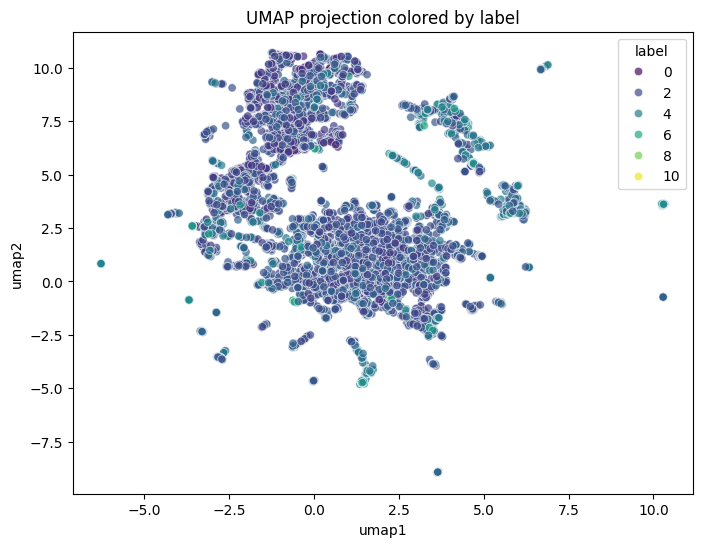

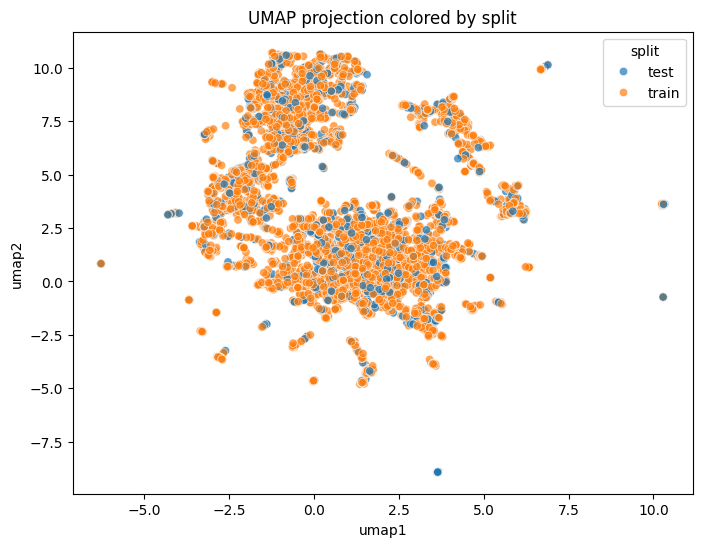

In [19]:
df = pd.read_csv("data/ld50_zhu.tab", sep="\t")
df = df.rename(columns={"X": "smiles", "Y": "label"})

df['mol'] = df['smiles'].apply(Chem.MolFromSmiles)
df = df[df['mol'].notnull()].reset_index(drop=True)

df['split'] = 'train'

train_idx, test_idx = train_test_split(
    df.index,
    test_size=0.2,
    random_state=42
)

df.loc[test_idx, 'split'] = 'test'

def mol_to_fp(mol, radius=2, nBits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=nBits
    )
    return np.array(fp)

X = np.array([
    mol_to_fp(m)
    for m in df['mol']
])

reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='jaccard',
    random_state=42
)

embedding = reducer.fit_transform(X)

df['umap1'] = embedding[:, 0]
df['umap2'] = embedding[:, 1]

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='umap1',
    y='umap2',
    hue='label',
    palette='viridis',
    alpha=0.7
)

plt.title("UMAP projection colored by label")
plt.show()

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x='umap1',
    y='umap2',
    hue='split',
    alpha=0.7
)

plt.title("UMAP projection colored by split")
plt.show()

#### Task 4.2. Is the Provided Split Chemically Meaningful?

[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerator
[21:07:15] DEPRECATION WARNING: please use MorganGenerat

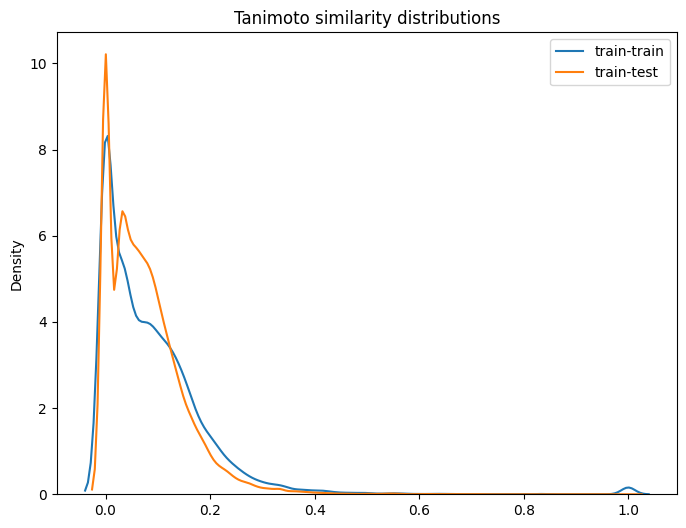

In [21]:
from rdkit.DataStructs import TanimotoSimilarity

fps = [
    AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048)
    for m in df['mol']
]

df['fp'] = fps

train_fps = df[df['split'] == 'train']['fp'].tolist()
test_fps = df[df['split'] == 'test']['fp'].tolist()

def compute_similarities(set1, set2, n_samples=200):

    sims = []

    for i in range(min(n_samples, len(set1))):
        for j in range(min(n_samples, len(set2))):

            sim = TanimotoSimilarity(
                set1[i],
                set2[j]
            )

            sims.append(sim)

    return sims

train_train_sim = compute_similarities(
    train_fps,
    train_fps
)

train_test_sim = compute_similarities(
    train_fps,
    test_fps
)

plt.figure(figsize=(8,6))

sns.kdeplot(
    train_train_sim,
    label='train-train'
)

sns.kdeplot(
    train_test_sim,
    label='train-test'
)

plt.legend()

plt.title("Tanimoto similarity distributions")

plt.show()

#### Task 4.3. Better Dataset Split

In [22]:
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None

    return MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol
    )

df['scaffold'] = df['smiles'].apply(
    get_scaffold
)

df = df[
    df['scaffold'].notnull()
].reset_index(drop=True)

scaffolds = df['scaffold'].unique()

train_scaff, test_scaff = train_test_split(
    scaffolds,
    test_size=0.2,
    random_state=42
)

df['scaffold_split'] = df['scaffold'].apply(
    lambda x: 'test' if x in test_scaff else 'train'
)

print(
    df['scaffold_split'].value_counts()
)

scaffold_split
train    6618
test      767
Name: count, dtype: int64


### Task 5. Dataset Diversity
#### Task 5.1. Dataset Diversity Analysis

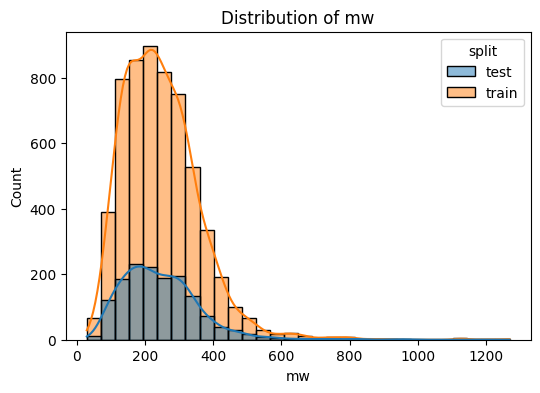

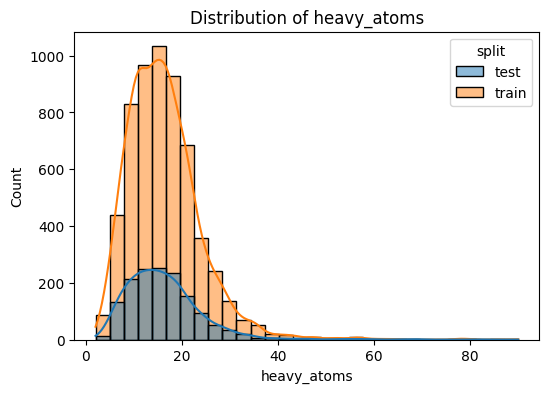

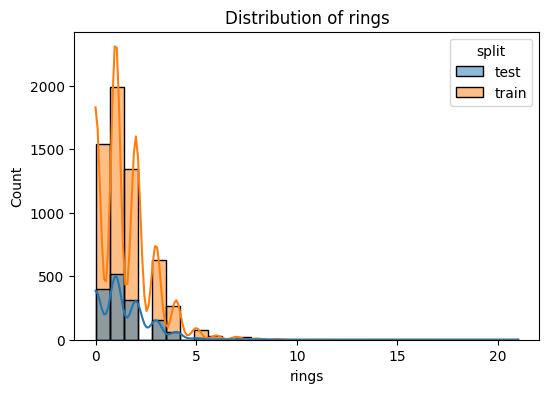

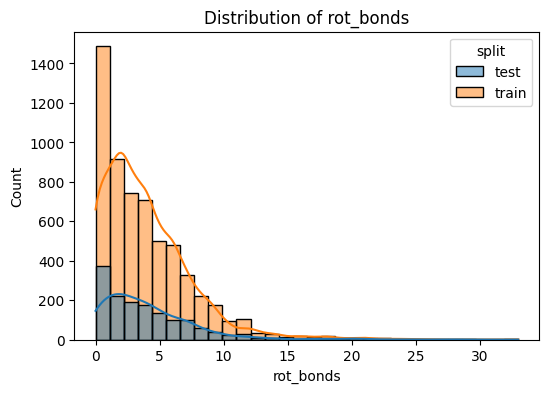

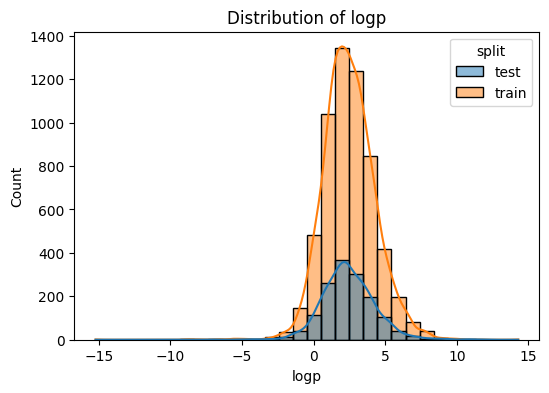

In [23]:


df['mw'] = df['mol'].apply(
    Descriptors.MolWt
)

df['heavy_atoms'] = df['mol'].apply(
    Descriptors.HeavyAtomCount
)

df['rings'] = df['mol'].apply(
    Descriptors.RingCount
)

df['rot_bonds'] = df['mol'].apply(
    Descriptors.NumRotatableBonds
)

df['logp'] = df['mol'].apply(
    Descriptors.MolLogP
)

features = [
    'mw',
    'heavy_atoms',
    'rings',
    'rot_bonds',
    'logp'
]

for feat in features:

    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=feat,
        hue='split',
        kde=True,
        bins=30
    )

    plt.title(
        f"Distribution of {feat}"
    )

    plt.show()

#### Task 5.2. Structure–Activity Relationships

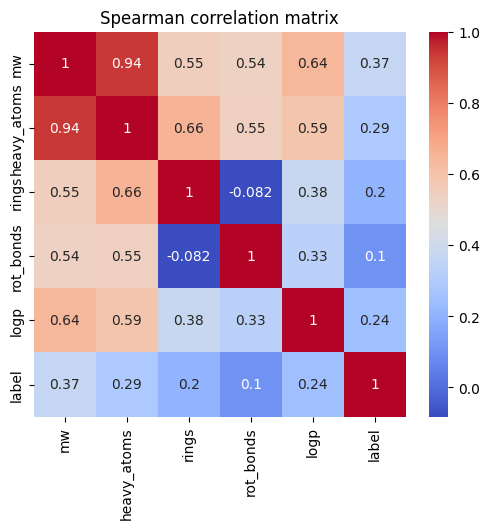

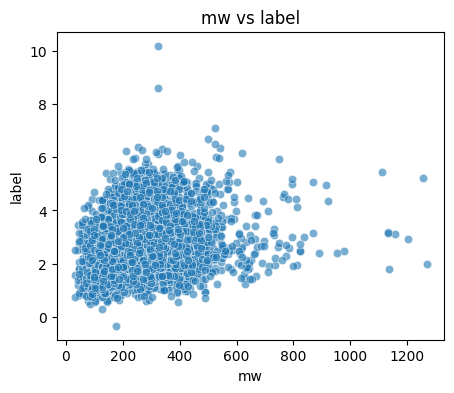

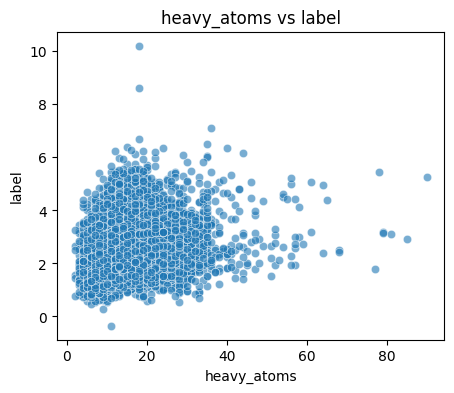

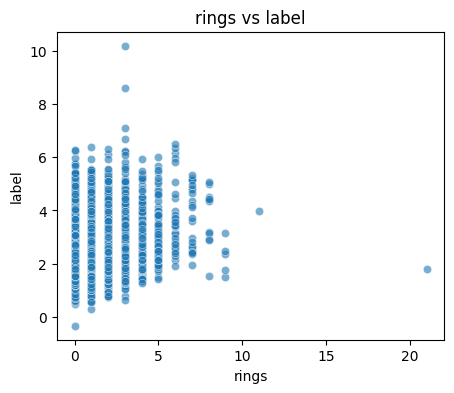

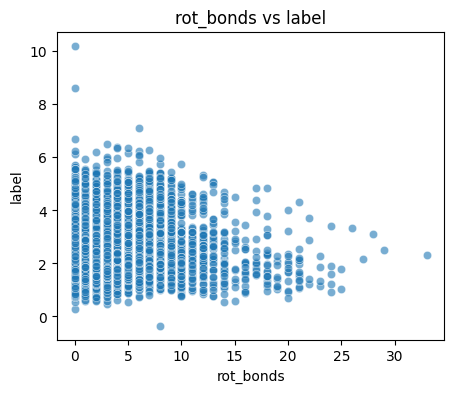

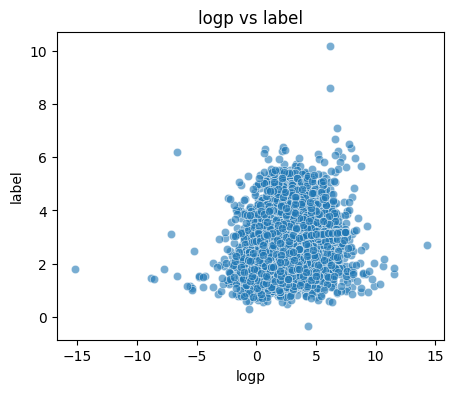

In [24]:
desc_df = df[
    features + ['label']
].dropna()

corr = desc_df.corr(
    method='spearman'
)

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title(
    "Spearman correlation matrix"
)

plt.show()

for feat in features:

    plt.figure(figsize=(5,4))

    sns.scatterplot(
        data=df,
        x=feat,
        y='label',
        alpha=0.6
    )

    plt.title(
        f"{feat} vs label"
    )

    plt.show()